<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l"outil plébiscité par les analystes de données Jupyter.

Il s"agit d"un outil permettant de mixer et d"alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d"un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l"approche suivie ou les résultats d"une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d"agrémenter de graphiques

Pour vous aider dans vos premiers pas à l"usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l"instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l"esprit, qu"il n"y a pas de solution unique pour résoudre un problème et qu"il y a autant de résolutions de problèmes que de développeurs ;)...



<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [1]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [2]:
#Importation du fichier population.csv

##attention aux anti-slash à mettre en slash pour ne pas avoir d"erreur
population = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/$P4/Données/population.csv")

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/$P4/Données/dispo_alimentaire.csv")

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/$P4/Données/aide_alimentaire.csv")

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv("D:/$27.12.2025 Ordinateur/$29.12.2025 Bureau/$GRETA/$P4/Données/sous_nutrition.csv")

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [3]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [4]:
#Consulter le nombre de colonnes
print(len(population.columns))
#La nature des données dans chacune des colonnes
print(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print(len(population.index))

##pour vérifier mes résultats de lignes et colonnes
print(population.shape)

3
Zone       object
Année       int64
Valeur    float64
dtype: object
1416
(1416, 3)


In [5]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [6]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population["Valeur"] = population["Valeur"]*1000

In [7]:
#changement du nom de la colonne Valeur par Population
population.rename(columns={"Valeur" : "Population"}, inplace=True)

##vérifier que le changement de nom à eu lieu dans le dataframe et non de façon temporaire
print(population.columns)

Index(['Zone', 'Année', 'Population'], dtype='object')


In [8]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head(5)

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [9]:
population["Zone"].unique().shape

(236,)

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [10]:
#Afficher les dimensions du dataset
dispo_alimentaire.shape

(15605, 18)

In [11]:
#Consulter le nombre de colonnes
dispo_alimentaire.shape[1]

18

In [12]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [13]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire.fillna(0, inplace=True)

##vérifier modifications
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53.0,0.0,0.0,53.0,0.0,53.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82.0,0.0,82.0,82.0,0.0,0.0,0.0,0.0,0.0


In [14]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
##population["Valeur"] = population["Valeur"]*1000

colonne_mult = ["Aliments pour animaux", "Autres Utilisations",
                "Disponibilité intérieure", "Exportations - Quantité",
                "Importations - Quantité", "Nourriture", "Pertes",
                "Production", "Semences", "Traitement", "Variation de stock"]

dispo_alimentaire[colonne_mult] = dispo_alimentaire[colonne_mult] * 1000000


In [15]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [16]:
#Afficher les dimensions du dataset
aide_alimentaire.shape

(1475, 4)

In [17]:
#Consulter le nombre de colonnes
aide_alimentaire.shape[1]

4

In [18]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [19]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire.rename(columns={"Pays bénéficiaire" : "Zone"}, inplace=True)

In [20]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire["Valeur"] = aide_alimentaire["Valeur"]*1000

In [21]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head(5)

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [22]:
#Afficher les dimensions du dataset
sous_nutrition.shape

(1218, 3)

In [23]:
#Consulter le nombre de colonnes
sous_nutrition.shape[1]

3

In [24]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [25]:
#Conversion de la colonne sous nutrition en numérique
sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce")

##vérifier types des colonnes
sous_nutrition.dtypes

Zone       object
Année      object
Valeur    float64
dtype: object

In [26]:
#Conversion de la colonne (avec l"argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0

sous_nutrition["Valeur"] = pd.to_numeric(sous_nutrition["Valeur"], errors="coerce")
sous_nutrition.fillna(0, inplace=True)

In [27]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition.rename(columns={"Valeur" : "sous_nutrition"}, inplace=True)

##vérifier nom des colonnes
print(sous_nutrition.columns)

Index(['Zone', 'Année', 'sous_nutrition'], dtype='object')


In [28]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition["sous_nutrition"] = sous_nutrition["sous_nutrition"]*1000000

In [29]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [30]:
# Il faut tout d"abord faire une jointure entre la table population et la table sous nutrition, en ciblant l"année 2017

##Filtrage data frame "population" pour l"année 2017
pop_2017 = population[population["Année"] == 2017]
##Filtrage data frame "sous_nutrition" pour l"année 2017 (2017 correspond à l"intervalle "2016-2018" dans le data frame)
snut_2017 = sous_nutrition[sous_nutrition["Année"] == "2016-2018"]

##Jointure entre les 2 tables
df_snut_2017 = pd.merge(pop_2017, snut_2017, on="Zone")

In [31]:
#Affichage du dataset
df_snut_2017.shape
df_snut_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0


In [32]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
total_sous_nut = df_snut_2017["sous_nutrition"].sum()
total_pop = df_snut_2017["Population"].sum()

print("Nombre total de personnes en sous-nutrition dans le monde en 2017 :"f"{total_sous_nut:,.0f}")
print("")
print("Population totale dans le monde en 2017 :"f"{total_pop:,.0f}")
print("")

proportion_mondiale = round((total_sous_nut / total_pop) * 100, 2)

print(f"Proportion de personnes en état de sous-nutrition en 2017 : {proportion_mondiale:.2f}%")
print("")
print("En 2017,", proportion_mondiale, "% de personne dans le monde sont en état de sous-nutrition.")



Nombre total de personnes en sous-nutrition dans le monde en 2017 :535,700,000

Population totale dans le monde en 2017 :7,543,798,779

Proportion de personnes en état de sous-nutrition en 2017 : 7.10%

En 2017, 7.1 % de personne dans le monde sont en état de sous-nutrition.


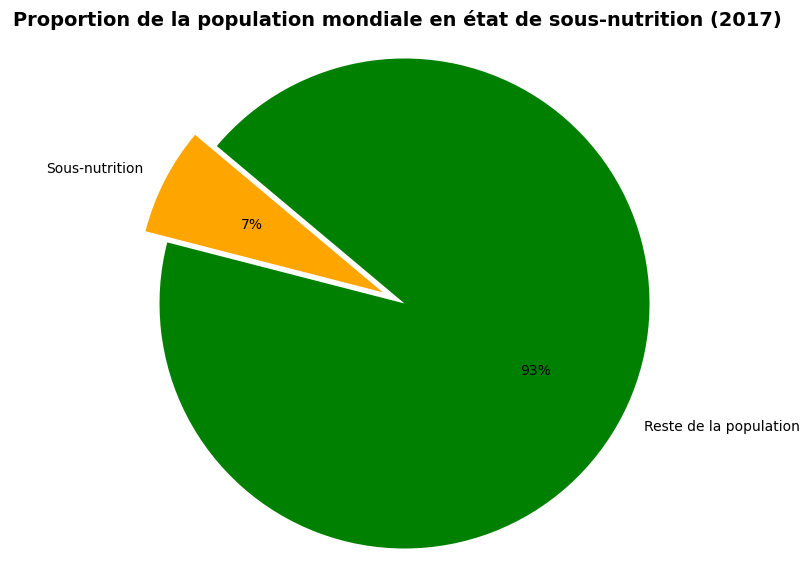

In [33]:
import matplotlib.pyplot as plt

##Préparation des données pour le graphique
labels = ["Sous-nutrition", "Reste de la population"]
tailles = [total_sous_nut, total_pop - total_sous_nut]
couleurs = ["orange", "green"] ##Rouge clair et Bleu
explode = (0.1, 0)  ##On "sort" légèrement la part en sous-nutrition pour la mettre en valeur

##Création du graphique
plt.figure(figsize=(10, 7))
plt.pie(tailles, explode=explode, labels=labels, autopct="%1.0f%%", startangle=140, colors=couleurs)

plt.title("Proportion de la population mondiale en état de sous-nutrition (2017)",
         fontsize=14,
         fontweight="bold")
plt.axis("equal")  ##Assure que le diagramme est un cercle parfait

##Affichage
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [34]:
#Combien mange en moyenne un être humain ? Source => https://www.nhs.uk/live-well/healthy-weight/managing-your-weight/understanding-calories/
##2500 kcal
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


In [35]:
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0


In [36]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d"ajouter dans ce dernier la population

##On isole la population de 2017 pour éviter les doublons lors de la jointure
pop_2017 = population.loc[population["Année"] == 2017, ["Zone", "Population"]]

##Jointure avec dispo_alimentaire
#On utilise une jointure à gauche (left) pour garder toutes les lignes du bilan alimentaire
dispo_alimentaire = pd.merge(dispo_alimentaire, pop_2017, on="Zone", how="left")

##Affichage pour vérifier
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0


In [37]:
#Affichage du nouveau dataframe
dispo_alimentaire.shape

(15605, 19)

In [38]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement

##Formule : dispo journalière * population * 365 jours
dispo_alimentaire["dispo_kcal_totale"] = dispo_alimentaire["Disponibilité alimentaire (Kcal/personne/jour)"] * dispo_alimentaire["Population"] * 365

display(dispo_alimentaire["dispo_kcal_totale"])
dispo_alimentaire.head()

0        6.624041e+10
1        1.324808e+10
2        1.324808e+10
3        0.000000e+00
4        5.299232e+10
             ...     
15600    1.044694e+10
15601    2.553697e+09
15602    0.000000e+00
15603    0.000000e+00
15604    9.286169e+08
Name: dispo_kcal_totale, Length: 15605, dtype: float64

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal_totale
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,0.0,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0,6.624041e+10
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,1.324808e+10
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,1.324808e+10
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,5.299232e+10


In [39]:
#Calcul du nombre d"humains pouvant être nourris

##Calcul de la disponibilité mondiale totale
total_kcal_monde = dispo_alimentaire["dispo_kcal_totale"].sum()

##Calcul du nombre d"humains potentiellement nourris
##On utilise la base de 2500 kcal par jour, soit 2500 * 365 par an
besoin_annuel_moyen = 2500 * 365
humains_nourris_potentiel = total_kcal_monde / besoin_annuel_moyen

print(f"Total des calories disponibles dans le monde : {total_kcal_monde:.2e} kcal")
print(f"Nombre d'humains pouvant être nourris : {humains_nourris_potentiel / 1e9:.2f} milliards (> 7,54 milliards)")

Total des calories disponibles dans le monde : 7.64e+15 kcal
Nombre d'humains pouvant être nourris : 8.37 milliards (> 7,54 milliards)


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [40]:
#Transfert des données avec les végétaux dans un nouveau dataframe

dispo_alimentaire["Origine"].unique()


array(['animale', 'vegetale'], dtype=object)

In [41]:
##On crée un nouveau DataFrame avec seulement les végétaux
dispo_vegetale = dispo_alimentaire.loc[dispo_alimentaire["Origine"] == "vegetale"]
dispo_vegetale.shape
dispo_vegetale.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal_totale
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,2000000.0,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,1.324808e+10
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,0.0,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,1.324808e+10
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,0.0,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,5.299232e+10
6,Afghanistan,Bière,vegetale,0.0,0.0,0.0,0.09,0.00,0.00,3000000.0,0.0,3000000.0,3000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00


In [42]:
#Calcul du nombre de kcal disponible avec les végétaux
total_kcal_vegetale = dispo_vegetale["dispo_kcal_totale"].sum()

#Calcul du nombre d"humains pouvant être nourris avec les végétaux
##On utilise la base de 2500 kcal par jour, soit 2500 * 365 par an
besoin_annuel_moyen = 2500 * 365
humains_nourris_potentiel = total_kcal_vegetale / besoin_annuel_moyen

print(f"Total des calories disponibles dans le monde avec les produits végétaux : {total_kcal_monde:.2e} kcal")
print(f"Nombre d'humains pouvant être nourris avec les produits végétaux : {humains_nourris_potentiel / 1e9:.2f} milliards (< 7,54 milliards)")

Total des calories disponibles dans le monde avec les produits végétaux : 7.64e+15 kcal
Nombre d'humains pouvant être nourris avec les produits végétaux : 6.90 milliards (< 7,54 milliards)


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure (Répartition de la disponibilité interieure)</h3>
</div>

In [43]:
#Calcul de la disponibilité totale

##Liste des colonnes correspondant aux différents usages (demandes spécifiques)
colonnes_usages = ["Semences", "Pertes", "Nourriture", "Aliments pour animaux", "Traitement", "Autres Utilisations"]

##Calcul de la disponibilité totale par produit/pays (disponibilité totale par ligne)
dispo_alimentaire["dispo_int_total_calcul_usage"] = dispo_alimentaire[colonnes_usages].sum(axis=1)

##Cumul du calcul de la disponibilité totale par produit/pays (disponibilité totale colonne finale)
cumul_dispo_int_total_calcul_usage = dispo_alimentaire["dispo_int_total_calcul_usage"].sum()

cumul_disponibilité_intérieure_col = dispo_alimentaire["Disponibilité intérieure"].sum()

print(cumul_dispo_int_total_calcul_usage)
display(dispo_alimentaire)

9858592000000.0


,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal_totale,dispo_int_total_calcul_usage
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0,6.624041e+10,53000000.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,1.324808e+10,41000000.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,1.324808e+10,2000000.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,5.299232e+10,82000000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15600,Îles Salomon,Viande de Suides,animale,0.0,0.0,45.0,4.70,4.28,1.41,3000000.0,...,0.0,3000000.0,0.0,2000000.0,0.0,0.0,0.0,636039.0,1.044694e+10,3000000.0
15601,Îles Salomon,Viande de Volailles,animale,0.0,0.0,11.0,3.34,0.69,1.14,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,636039.0,2.553697e+09,2000000.0
15602,Îles Salomon,"Viande, Autre",animale,0.0,0.0,0.0,0.06,0.00,0.04,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00,0.0
15603,Îles Salomon,Vin,vegetale,0.0,0.0,0.0,0.07,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,636039.0,0.000000e+00,0.0


In [44]:
#création d"une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures

for col in colonnes_usages:
    valeur_totale = dispo_alimentaire[col].sum()
    ##Résultat en kg
    print(f"Total pour {col:25} : {valeur_totale:15,.0f} kg")



Total pour Semences                  : 154,681,000,000 kg
Total pour Pertes                    : 453,698,000,000 kg
Total pour Nourriture                : 4,876,258,000,000 kg
Total pour Aliments pour animaux     : 1,304,245,000,000 kg
Total pour Traitement                : 2,204,687,000,000 kg
Total pour Autres Utilisations       : 865,023,000,000 kg


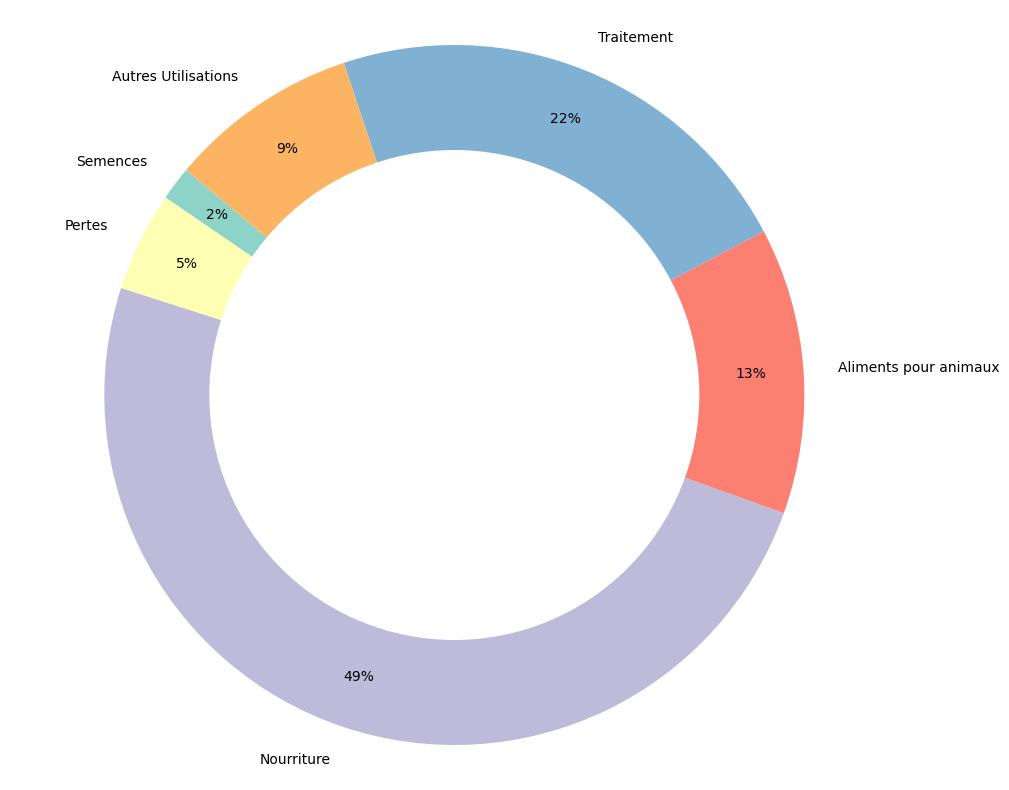

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcul des données
libelles = []
valeurs = []

for col in colonnes_usages:
    valeur_totale = dispo_alimentaire[col].sum()
    libelles.append(col)
    valeurs.append(valeur_totale)

# 2. Création du graphique
plt.figure(figsize=(10, 8))

# On utilise x= pour éviter l"erreur de version vue précédemment
plt.pie(x=valeurs, 
        labels=libelles, 
        autopct="%1.0f%%", 
        startangle=140, 
        pctdistance=0.85, # Place le % proche du bord intérieur
        #colors = plt.cm.GnBu(np.linspace(0.4, 0.8, len(libelles))))
        colors=plt.cm.Set3.colors) # Palette de couleurs variées

# Ajout d"un cercle au centre pour en faire un "Donut Chart" (plus moderne)
centre_cercle = plt.Circle((0,0), 0.70, fc="white")
fig = plt.gcf()
fig.gca().add_artist(centre_cercle)

#plt.title("Répartition des composantes de la disponibilité intérieure", fontsize=14, fontweight="bold")
plt.axis("equal") 
plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [46]:
#Création d"une liste avec toutes les variables
dispo_alimentaire.columns

Index(['Zone', 'Produit', 'Origine', 'Aliments pour animaux',
       'Autres Utilisations', 'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité intérieure', 'Exportations - Quantité',
       'Importations - Quantité', 'Nourriture', 'Pertes', 'Production',
       'Semences', 'Traitement', 'Variation de stock', 'Population',
       'dispo_kcal_totale', 'dispo_int_total_calcul_usage'],
      dtype='object')

In [47]:
dispo_alimentaire["Produit"].unique()

array(['Abats Comestible', 'Agrumes, Autres', 'Aliments pour enfants',
       'Ananas', 'Bananes', 'Beurre, Ghee', 'Bière', 'Blé',
       'Boissons Alcooliques', 'Café', 'Coco (Incl Coprah)', 'Crème',
       'Céréales, Autres', 'Dattes', 'Edulcorants Autres',
       'Feve de Cacao', 'Fruits, Autres', 'Graines de coton',
       'Graines de tournesol', 'Graisses Animales Crue',
       'Huil Plantes Oleif Autr', 'Huile Graines de Coton',
       "Huile d'Arachide", "Huile d'Olive", 'Huile de Colza&Moutarde',
       'Huile de Palme', 'Huile de Soja', 'Huile de Sésame',
       'Huile de Tournesol', 'Lait - Excl Beurre', 'Légumes, Autres',
       'Légumineuses Autres', 'Maïs', 'Miel', 'Millet', 'Miscellanees',
       'Noix', 'Oeufs', 'Olives', 'Oranges, Mandarines', 'Orge',
       'Plantes Oleiferes, Autre', 'Poissons Eau Douce', 'Poivre',
       'Pommes', 'Pommes de Terre', 'Raisin', 'Riz (Eq Blanchi)',
       'Sucre Eq Brut', 'Sucre, betterave', 'Sucre, canne', 'Sésame',
       'Thé', 'Toma

In [48]:
##Création liste avec toutes les céréales
liste_cereales = ["Blé", "Riz (Eq Blanchi)", "Orge", "Maïs", "Seigle", 
                  "Avoine", "Millet", "Sorgho", "Céréales, Autres"]

In [49]:
#Création d"un dataframe avec les informations uniquement pour ces céréales

#Data frame regroupant les différentes céréales
df_cereales = dispo_alimentaire.loc[dispo_alimentaire["Produit"].isin(liste_cereales)]
df_cereales.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal_totale,dispo_int_total_calcul_usage
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5.992000e+09,...,1.173000e+09,4.895000e+09,775000000.0,5.169000e+09,322000000.0,0.0,-350000000.0,36296113.0,1.813662e+13,5.992000e+09
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,36296113.0,0.000000e+00,0.000000e+00
32,Afghanistan,Maïs,vegetale,200000000.0,0.0,21.0,2.50,0.30,0.56,3.130000e+08,...,1.000000e+06,7.600000e+07,31000000.0,3.120000e+08,5000000.0,0.0,0.0,36296113.0,2.782097e+11,3.120000e+08
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,1.300000e+07,...,0.000000e+00,1.200000e+07,1000000.0,1.300000e+07,0.0,0.0,0.0,36296113.0,3.974424e+10,1.300000e+07
40,Afghanistan,Orge,vegetale,360000000.0,0.0,26.0,2.92,0.24,0.79,5.240000e+08,...,1.000000e+07,8.900000e+07,52000000.0,5.140000e+08,22000000.0,0.0,0.0,36296113.0,3.444501e+11,5.230000e+08


In [50]:
#Affichage de la proportion d"alimentation animale

##On calcule les totaux globaux
total_alimentation_animale = df_cereales["Aliments pour animaux"].sum()
total_dispo_interieure = df_cereales["Disponibilité intérieure"].sum()

##Calcul du pourcentagetotal_dispo_interieure
proportion_animale = (total_alimentation_animale / total_dispo_interieure) * 100

print(f"La proportion de céréales destinées à l'alimentation animale est de : {proportion_animale:.2f}%")

La proportion de céréales destinées à l'alimentation animale est de : 36.29%


In [51]:
#Affichage de la proportion d"alimentation animale

total_cereales_nourriture = df_cereales["Nourriture"].sum()

##Calcul du pourcentage
proportion_nourriture_humain = (total_cereales_nourriture / total_dispo_interieure) * 100

print(f"La proportion de céréales destinées à la nourriture est de : {proportion_nourriture_humain:.2f}%")

La proportion de céréales destinées à la nourriture est de : 42.75%


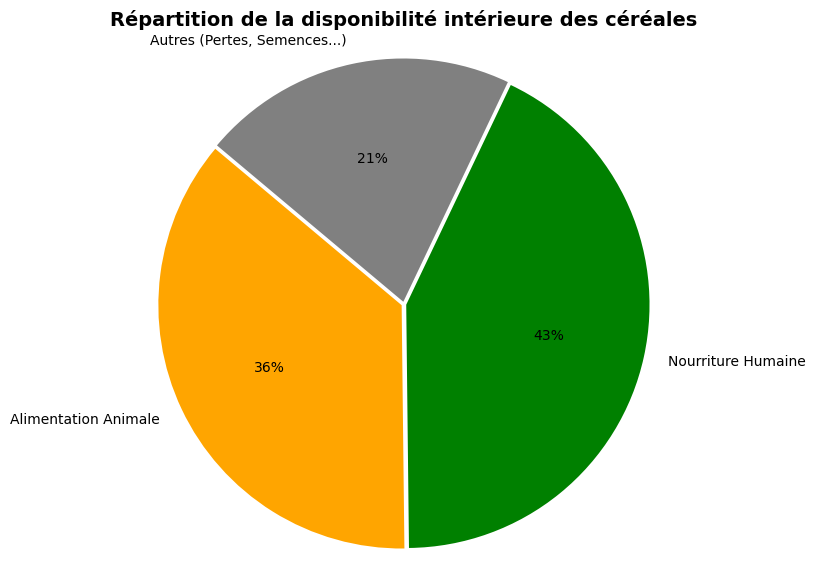

In [52]:
#Affichage de la proportion d"alimentation animale

import matplotlib.pyplot as plt

# 2. CALCULER "total_autres" AVANT de l"utiliser
# Remplacez "total_global" par le nom de votre variable qui contient le total
total_autres = total_dispo_interieure - (total_alimentation_animale + total_cereales_nourriture)

# Préparation des données
labels = ["Alimentation Animale", "Nourriture Humaine", "Autres (Pertes, Semences...)"]
# On calcule la part "Autres" en soustrayant l"animal du total
parts = [total_alimentation_animale, total_cereales_nourriture, total_autres]
colors = ["orange", "green", "grey"] # Jaune pour les animaux, vert pour le reste
explode = (0.1, 0.1, 0.1)
  
# Création du graphique
plt.figure(figsize=(10, 7))
#plt.pie(tailles, explode=explode, labels=labels, autopct="%1.1f%%", startangle=140, colors=couleurs)
plt.pie(parts, labels=labels, autopct="%1.f%%", startangle=140, colors=colors, explode=(0.01, 0.01, 0.01))

plt.title("Répartition de la disponibilité intérieure des céréales", fontsize=14, fontweight="bold")
plt.axis("equal")  # Assure que le diagramme est un cercle parfait
plt.show()


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [53]:
#Création de la colonne proportion par pays


In [54]:
df_snut_2017.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0
1,Afrique du Sud,2017,57009756.0,2016-2018,3100000.0
2,Albanie,2017,2884169.0,2016-2018,100000.0
3,Algérie,2017,41389189.0,2016-2018,1300000.0
4,Allemagne,2017,82658409.0,2016-2018,0.0


In [55]:
df_snut_2017["Proportion_pays"] = (df_snut_2017["sous_nutrition"]) / df_snut_2017["Population"] * 100

##On arrondit à 2 décimales
df_snut_2017["Proportion_pays"] = df_snut_2017["Proportion_pays"].round(2)


df_snut_2017[["Zone", "sous_nutrition", "Population", "Proportion_pays"]].head()

,Zone,sous_nutrition,Population,Proportion_pays
0,Afghanistan,10500000.0,36296113.0,28.93
1,Afrique du Sud,3100000.0,57009756.0,5.44
2,Albanie,100000.0,2884169.0,3.47
3,Algérie,1300000.0,41389189.0,3.14
4,Allemagne,0.0,82658409.0,0.00


In [56]:
#affichage après trie des 10 pires pays

pires_pays = df_snut_2017.sort_values(by="Proportion_pays", ascending=False)

display(pires_pays.head(10))

,Zone,Année_x,Population,Année_y,sous_nutrition,Proportion_pays
78,Haïti,2017,10982366.0,2016-2018,5300000.0,48.26
157,République populaire démocratique de Corée,2017,25429825.0,2016-2018,12000000.0,47.19
108,Madagascar,2017,25570512.0,2016-2018,10500000.0,41.06
103,Libéria,2017,4702226.0,2016-2018,1800000.0,38.28
100,Lesotho,2017,2091534.0,2016-2018,800000.0,38.25
183,Tchad,2017,15016753.0,2016-2018,5700000.0,37.96
161,Rwanda,2017,11980961.0,2016-2018,4200000.0,35.06
121,Mozambique,2017,28649018.0,2016-2018,9400000.0,32.81
186,Timor-Leste,2017,1243258.0,2016-2018,400000.0,32.17
0,Afghanistan,2017,36296113.0,2016-2018,10500000.0,28.93


In [57]:
##sélection de mes colonne pour diapo
pires_pays = pires_pays.loc[:, ["Zone", "Année_x", "Population", "sous_nutrition", "Proportion_pays"]]

##renomme colonne
pires_pays = pires_pays.rename(columns={"Année_x": "Année"})

##Remplacer "République populaire démocratique de Corée" par un autre nom
##pires_pays["Zone"] = pires_pays["Zone"].replace("République populaire démocratique de Corée", "Rép. Pop. Démo. de Corée")

display(pires_pays.head(10))

,Zone,Année,Population,sous_nutrition,Proportion_pays
78,Haïti,2017,10982366.0,5300000.0,48.26
157,République populaire démocratique de Corée,2017,25429825.0,12000000.0,47.19
108,Madagascar,2017,25570512.0,10500000.0,41.06
103,Libéria,2017,4702226.0,1800000.0,38.28
100,Lesotho,2017,2091534.0,800000.0,38.25
183,Tchad,2017,15016753.0,5700000.0,37.96
161,Rwanda,2017,11980961.0,4200000.0,35.06
121,Mozambique,2017,28649018.0,9400000.0,32.81
186,Timor-Leste,2017,1243258.0,400000.0,32.17
0,Afghanistan,2017,36296113.0,10500000.0,28.93


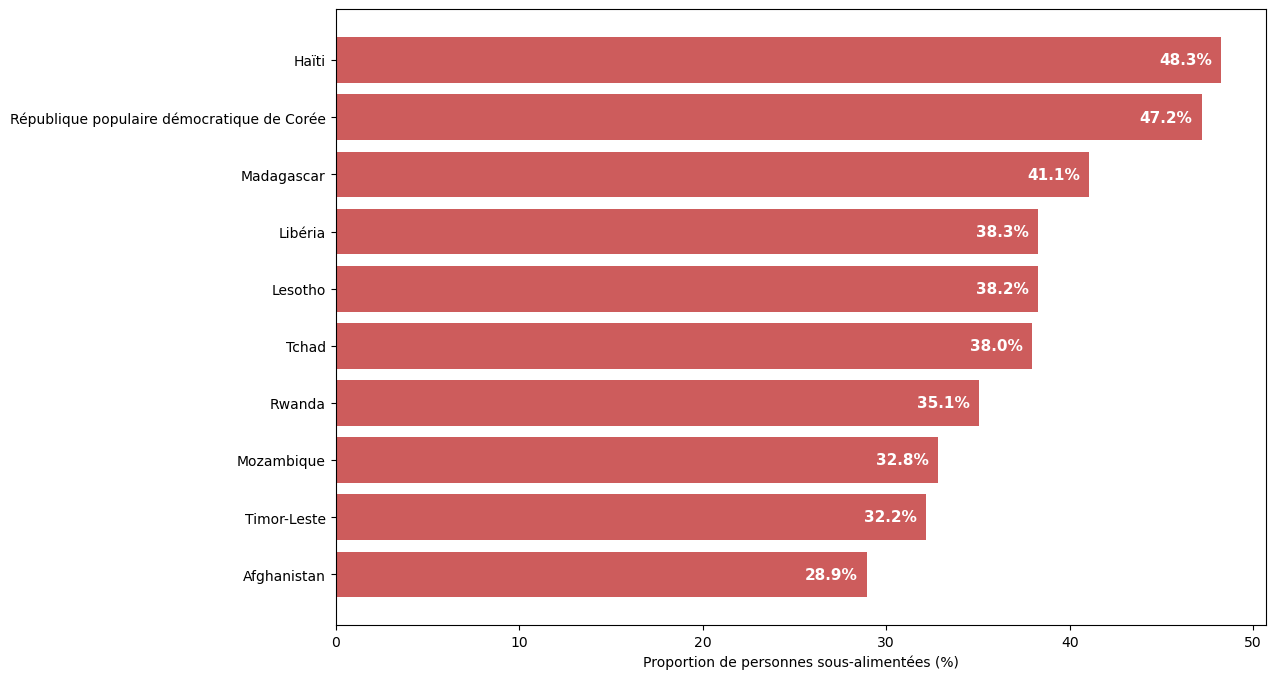

In [58]:
import matplotlib.pyplot as plt

# 1. On isole les 10 pays avec la plus forte proportion
# On trie par ordre décroissant (le plus gros en premier)
top_10_sous_nutrition = pires_pays.sort_values(by="Proportion_pays", ascending=False).head(10)

# 2. On inverse l"ordre pour que la plus grande barre soit en HAUT sur le graphique horizontal
top_10_sous_nutrition = top_10_sous_nutrition.iloc[::-1]

# 3. Création du graphique
plt.figure(figsize=(12, 8))
# On utilise une couleur rouge/orangée pour souligner la gravité
bars = plt.barh(top_10_sous_nutrition["Zone"], top_10_sous_nutrition["Proportion_pays"], color="indianred")

# 4. Ajout des valeurs À L"INTÉRIEUR des barres
for bar in bars:
    width = bar.get_width()
    # On place le texte un peu avant la fin de la barre (width - offset)
    # ha="right" aligne le texte sur la droite du point donné
    plt.text(width - 0.5, 
             bar.get_y() + bar.get_height()/2, 
             f"{width:.1f}%", 
             va="center", 
             ha="right", 
             color="white",      # Couleur blanche pour que ce soit lisible sur le rouge
             fontweight="bold",
             fontsize=11)

plt.xlabel("Proportion de personnes sous-alimentées (%)")
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d"aide alimentaire depuis 2013</h3>
</div>

In [59]:
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


In [60]:
#calcul du total de l"aide alimentaire par pays
cumul_aide_alimentaire = aide_alimentaire.groupby("Zone", as_index=False)["Valeur"].sum() #as_index=False permet de conserver le nom des colonnes
cumul_aide_alimentaire.head()

,Zone,Valeur
0,Afghanistan,185452000
1,Algérie,81114000
2,Angola,5014000
3,Bangladesh,348188000
4,Bhoutan,2666000


In [61]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l"aide alimentaire
pays_max_aide = cumul_aide_alimentaire.sort_values(by="Valeur", ascending=False)
pays_max_aide.head(10)

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


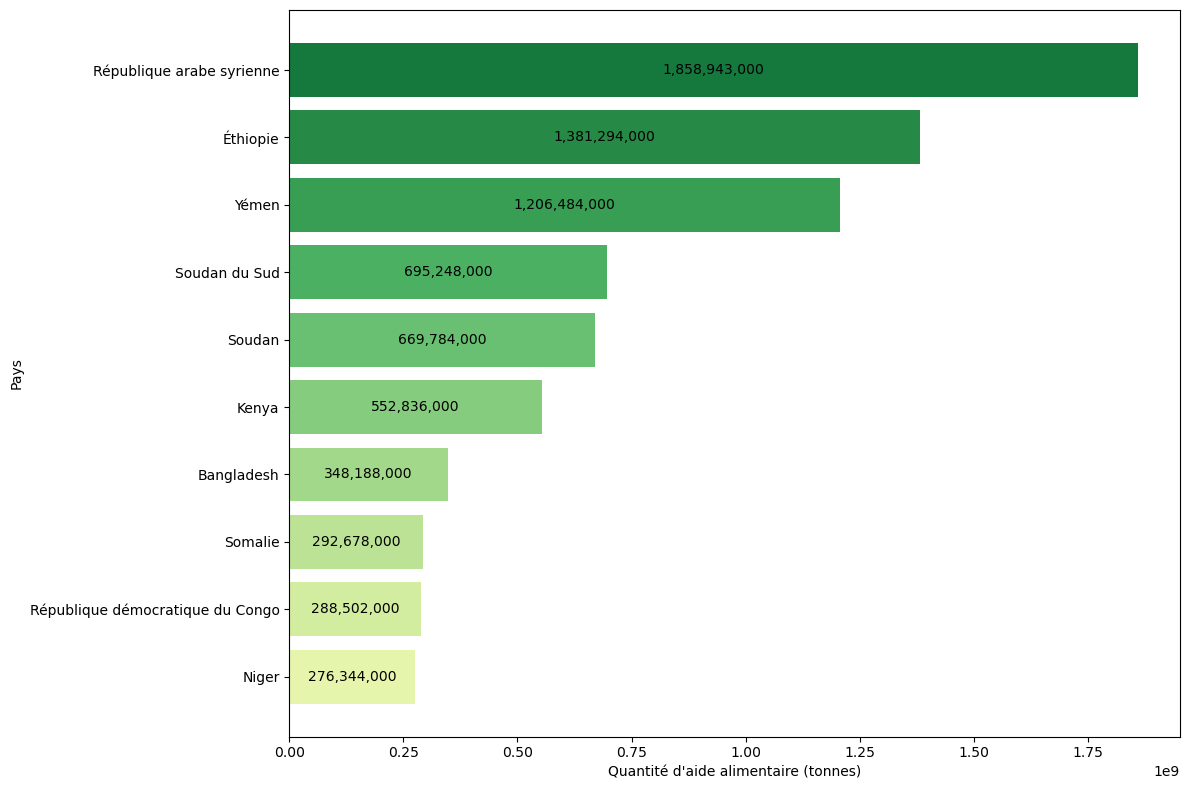

In [62]:
import matplotlib.pyplot as plt
import numpy as np

top_10_pays = cumul_aide_alimentaire.sort_values(by="Valeur", ascending=False).head(10)
top_10_plot = top_10_pays.iloc[::-1]

colors = plt.cm.YlGn(np.linspace(0.2, 0.8, len(top_10_plot)))

plt.figure(figsize=(12, 8))

bars = plt.barh(top_10_plot["Zone"], top_10_plot["Valeur"], color=colors)

plt.bar_label(bars, label_type="center", color="black", fmt="{:,.0f}")

plt.xlabel("Quantité d'aide alimentaire (tonnes)")
plt.ylabel("Pays")
#plt.title("Top 10 des pays bénéficiant le plus de l'aide alimentaire")
plt.tight_layout()

plt.show()

In [63]:
print(len(top_10_pays))

10


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l"aide alimentaire entre 2013 et 2016</h3>
</div>

In [64]:
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


In [65]:
#Création d"un dataframe avec la zone, l"année et l"aide alimentaire puis groupby sur zone et année 
cumul_aide_alimentaire = aide_alimentaire.groupby(["Zone", "Année"], as_index=False)["Valeur"].sum()
#as_index=False permet de conserver le nom des colonnes

cumul_aide_alimentaire.head()

,Zone,Année,Valeur
0,Afghanistan,2013,128238000
1,Afghanistan,2014,57214000
2,Algérie,2013,35234000
3,Algérie,2014,18980000
4,Algérie,2015,17424000


In [66]:
#Création d"une liste contenant les 5 pays qui ont le plus bénéficiées de l"aide alimentaire
top_5 = ["République arabe syrienne", "Éthiopie", "Yémen", "Soudan du Sud", "Soudan"]

In [67]:
#On filtre sur le dataframe avec notre liste
filtre_pays = cumul_aide_alimentaire[cumul_aide_alimentaire["Zone"].isin(top_5)]

In [68]:
# Affichage des pays avec l"aide alimentaire par année
display(filtre_pays)

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


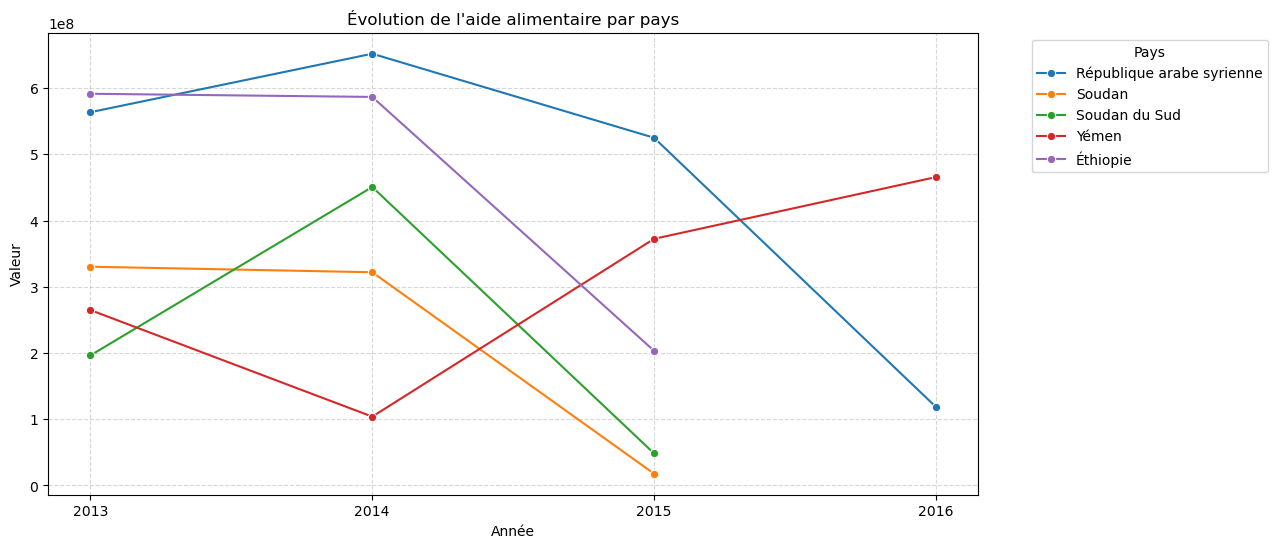

In [69]:
##Graphique

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(12, 6))

# On trace la courbe
plot = sns.lineplot(data=filtre_pays, x="Année", y="Valeur", hue="Zone", marker="o")

# --- L"ASTUCE POUR LES ANNÉES ENTIÈRES ---
plot.xaxis.set_major_locator(MaxNLocator(integer=True))
# ------------------------------------------

plt.title("Évolution de l'aide alimentaire par pays")
plt.xlabel("Année")
plt.ylabel("Valeur")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Pays", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [70]:
dispo_alimentaire.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal_totale,dispo_int_total_calcul_usage
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000000.0,...,0.0,53000000.0,0.0,53000000.0,0.0,0.0,0.0,36296113.0,6.624041e+10,53000000.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000000.0,...,40000000.0,39000000.0,2000000.0,3000000.0,0.0,0.0,0.0,36296113.0,1.324808e+10,41000000.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000000.0,...,2000000.0,2000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,1.324808e+10,2000000.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36296113.0,0.000000e+00,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000000.0,...,82000000.0,82000000.0,0.0,0.0,0.0,0.0,0.0,36296113.0,5.299232e+10,82000000.0


In [71]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alimentaire_pays = dispo_alimentaire.groupby("Zone", as_index=False)["Disponibilité alimentaire (Kcal/personne/jour)"].sum()
dispo_alimentaire_pays.head()


,Zone,Disponibilité alimentaire (Kcal/personne/jour)
0,Afghanistan,2087.0
1,Afrique du Sud,3020.0
2,Albanie,3188.0
3,Algérie,3293.0
4,Allemagne,3503.0


In [72]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
dispo_alimentaire_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)").head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,République populaire démocratique de Corée,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
154,Timor-Leste,2129.0


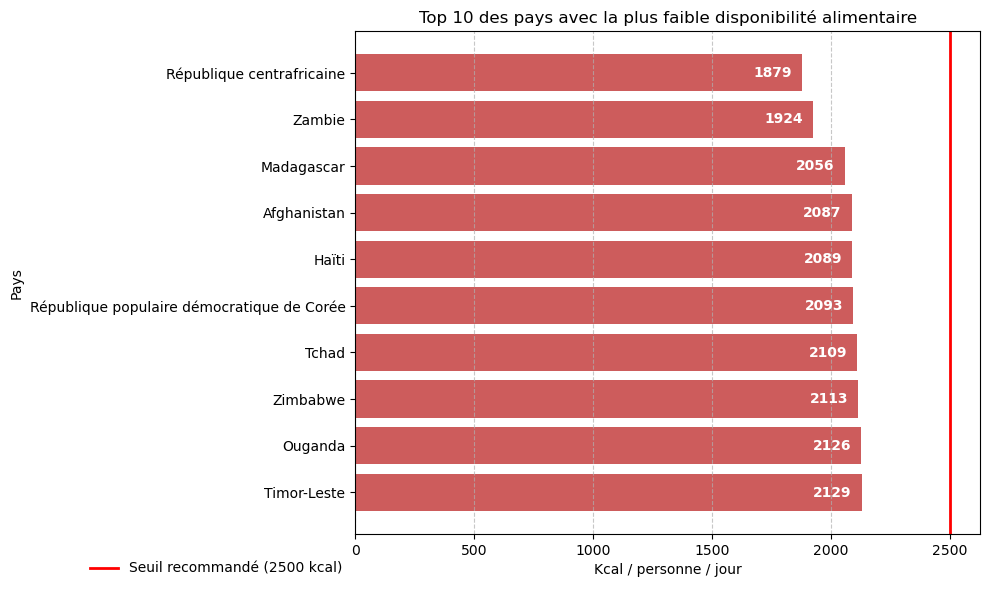

In [73]:
import matplotlib.pyplot as plt

dix_pires = dispo_alimentaire_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)").head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(dix_pires["Zone"], 
                dix_pires["Disponibilité alimentaire (Kcal/personne/jour)"], 
                color="indianred")

plt.axvline(x=2500, color="red", linestyle="-", linewidth=2, label="Seuil recommandé (2500 kcal)")

plt.bar_label(bars, label_type="edge", padding=-35, color="white", fontweight="bold", fmt="%.0f")

plt.xlabel("Kcal / personne / jour")
plt.ylabel("Pays")
plt.title("Top 10 des pays avec la plus faible disponibilité alimentaire")

plt.gca().invert_yaxis() 
plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.legend(loc="upper right", bbox_to_anchor=(0, -0.03), ncol=1, frameon=False)

plt.tight_layout() 

plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [74]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
dispo_alimentaire_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


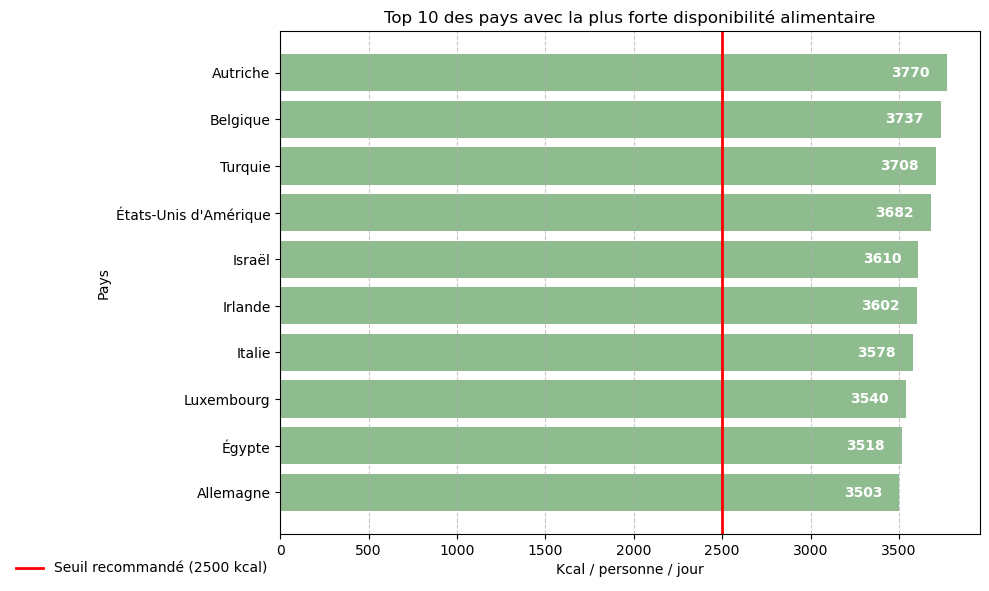

In [75]:
import matplotlib.pyplot as plt
import numpy as np

dix_meilleurs = dispo_alimentaire_pays.sort_values(by="Disponibilité alimentaire (Kcal/personne/jour)", ascending=False).head(10)

plt.figure(figsize=(10, 6))

bars = plt.barh(dix_meilleurs["Zone"], 
                dix_meilleurs["Disponibilité alimentaire (Kcal/personne/jour)"], 
                color="darkseagreen")

##axe du seuil recommandé
plt.axvline(x=2500, color="red", linestyle="-", linewidth=2, label="Seuil recommandé (2500 kcal)")

plt.bar_label(bars, label_type="edge", padding=-40, color="white", fontweight="bold", fmt="%.0f")

plt.xlabel("Kcal / personne / jour")
plt.ylabel("Pays")
plt.title("Top 10 des pays avec la plus forte disponibilité alimentaire")

plt.gca().invert_yaxis() 

plt.legend(loc="upper right", bbox_to_anchor=(0,   -0.03), ncol=1, frameon=False)

plt.grid(axis="x", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [76]:
##dispo_alimentaire["Zone"].unique()

In [77]:
##dispo_alimentaire["Produit"].unique()

In [78]:
#création d"un dataframe avec uniquement la Thaïlande 
pop_thai_2017 = population[(population["Année"] == 2017) & (population["Zone"] == "Thaïlande")]
pop_thai_2017.head()

,Zone,Année,Population
1312,Thaïlande,2017,69209810.0


In [79]:
#Calcul de la sous nutrition en Thaïlande
snut_thai_2017 = sous_nutrition[(sous_nutrition["Année"] == "2016-2018") & (sous_nutrition["Zone"] == "Thaïlande")]
snut_thai_2017.head()

,Zone,Année,sous_nutrition
1114,Thaïlande,2016-2018,6200000.0


In [80]:
##jointure pop et sous_nut en Thaïlande
data_thai = pd.merge(pop_thai_2017, snut_thai_2017, on="Zone")
data_thai.head()

,Zone,Année_x,Population,Année_y,sous_nutrition
0,Thaïlande,2017,69209810.0,2016-2018,6200000.0


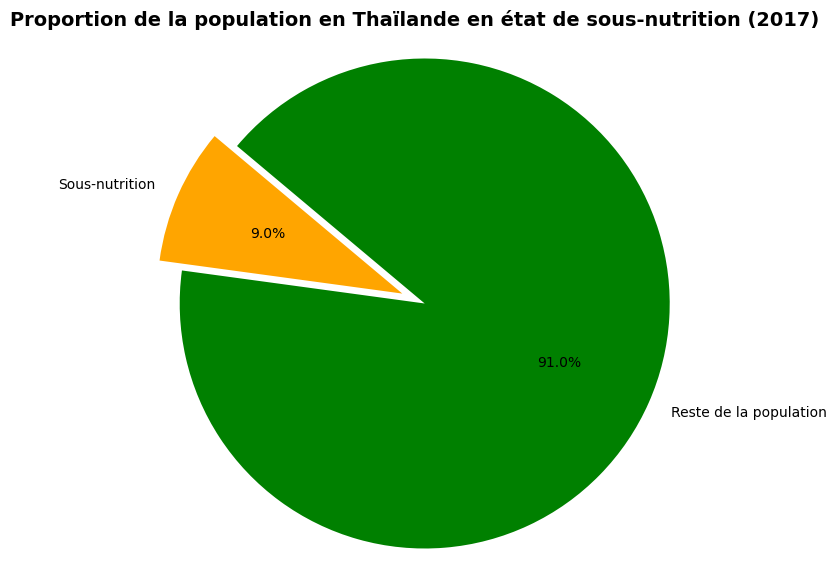

In [81]:
# Préparation des données
# On utilise .sum() ou .values[0] pour s"assurer d"avoir un nombre, pas une série
valeur_sous_nut = snut_thai_2017["sous_nutrition"].sum()
valeur_pop_totale = pop_thai_2017["Population"].sum()

labels = ["Sous-nutrition", "Reste de la population"]
tailles = [valeur_sous_nut, valeur_pop_totale - valeur_sous_nut]
couleurs = ["orange", "green"]
explode = (0.1, 0)

# Création du graphique
plt.figure(figsize=(10, 7))
plt.pie(x=tailles, explode=explode, labels=labels, autopct="%1.1f%%", startangle=140, colors=couleurs)

plt.title("Proportion de la population en Thaïlande en état de sous-nutrition (2017)", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.show()

In [82]:
# On calcule la proportion exportée en fonction de la proportion produite

manioc_thai = dispo_alimentaire[(dispo_alimentaire["Zone"] == "Thaïlande") & (dispo_alimentaire["Produit"] == "Manioc")]
manioc_thai.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,...,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Population,dispo_kcal_totale,dispo_int_total_calcul_usage
13809,Thaïlande,Manioc,vegetale,1.800000e+09,2.081000e+09,40.0,13.0,0.05,0.14,6.264000e+09,...,1.250000e+09,871000000.0,1.511000e+09,3.022800e+10,0.0,0.0,0.0,69209810.0,1.010463e+12,6.263000e+09


In [83]:
proportion_exportee_manioc = manioc_thai["Exportations - Quantité"] / manioc_thai["Production"] * 100

valeur_manioc = round(proportion_exportee_manioc.iloc[0],2)
print(valeur_manioc)

83.41


In [84]:
print(f"La proportion de manioc exportée de Thaïlande correspond à {valeur_manioc} %")

La proportion de manioc exportée de Thaïlande correspond à 83.41 %


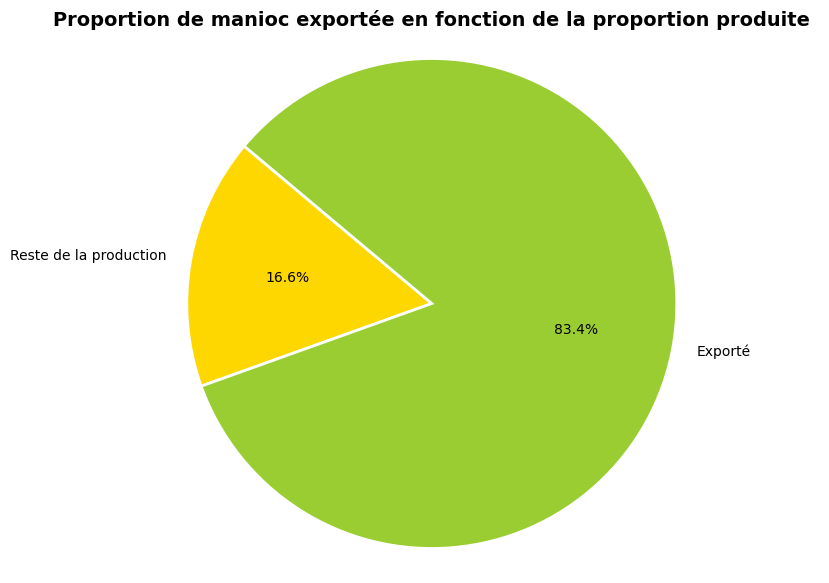

In [85]:
# Préparation des données
# On utilise .sum() ou .values[0] pour s"assurer d"avoir un nombre, pas une série
valeur_sous_nut = snut_thai_2017["sous_nutrition"].sum()
valeur_pop_totale = pop_thai_2017["Population"].sum()

labels = ["Reste de la production", "Exporté"]
tailles = [100-valeur_manioc, valeur_manioc]
couleurs = ["gold", "yellowgreen"]
explode = (0.1, 0)

# Création du graphique
plt.figure(figsize=(10, 7))
plt.pie(x=tailles,
        #explode=explode,
        labels=labels,
        autopct="%1.1f%%",
        startangle=140,
        colors=couleurs,
       wedgeprops={"edgecolor": "white", "linewidth": 2})

plt.title("Proportion de manioc exportée en fonction de la proportion produite", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.show()

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 6 - Analyse complémentaires</h2>
</div>

In [86]:
#ajouter en dessous toutes les analyses complémtaires

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Étude complémentaire - Répartition de l"utilisation des céréales par catégorie</h3>
</div>

In [87]:
##Calcul de la colonne "Autres"
df_cereales = df_cereales.copy() # Pour éviter les warnings de copie
df_cereales["Autres"] = df_cereales["Disponibilité intérieure"] - (df_cereales["Aliments pour animaux"] + df_cereales["Nourriture"])

##Groupement par nature de céréales
repartition_par_produit = df_cereales.groupby("Produit")[["Aliments pour animaux", "Nourriture", "Autres"]].sum()

##Calcul de la répartition pour chaque céréale par utilisation
repartition_pct = repartition_par_produit.div(repartition_par_produit.sum(axis=1), axis=0) * 100

##Affichage tableau
display(repartition_pct)

,Aliments pour animaux,Nourriture,Autres
Produit,,,
Avoine,69.427949,16.674499,13.897552
Blé,19.082911,67.376799,13.540290
"Céréales, Autres",69.255958,19.370566,11.373476
Maïs,57.137118,13.097314,29.765568
Millet,11.052790,77.028518,11.918692
Orge,65.977399,4.837688,29.184913
Riz (Eq Blanchi),7.062667,79.319088,13.618245
Seigle,48.886340,33.210599,17.903060
Sorgho,42.598348,41.473634,15.928018


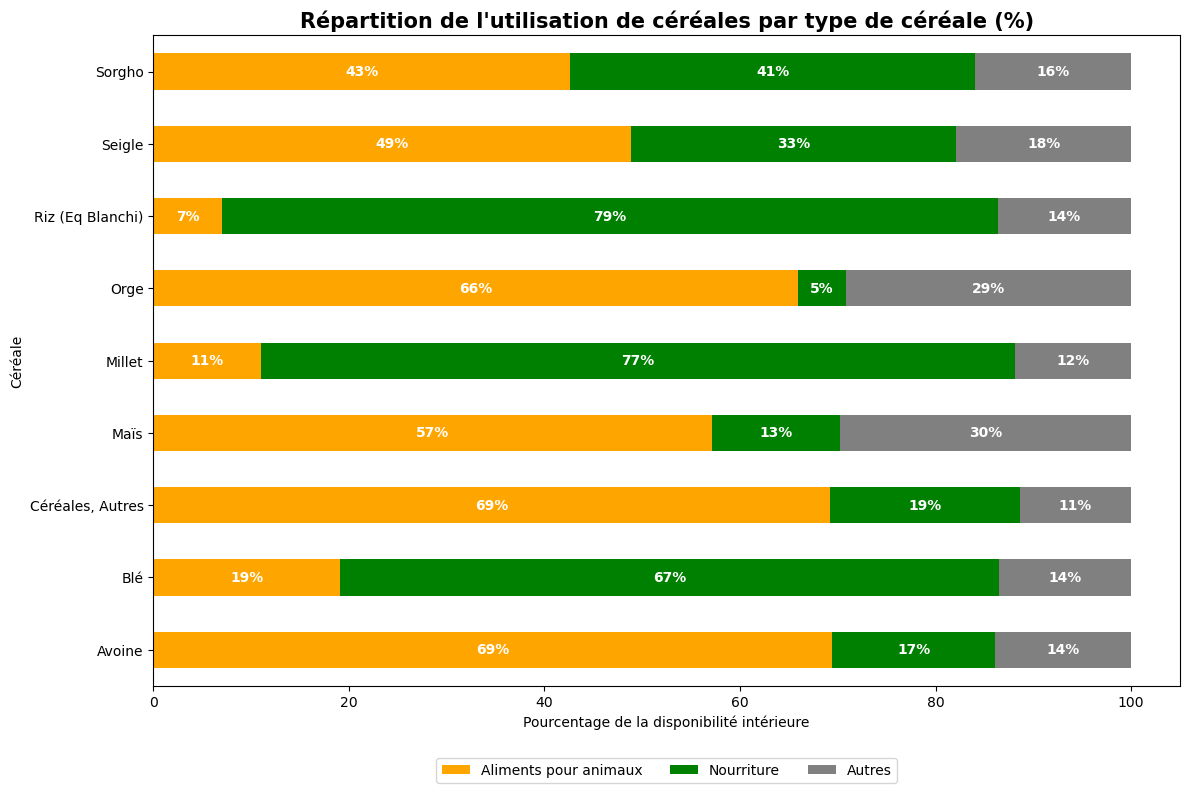

In [88]:
import matplotlib.pyplot as plt

# Création du graphique
ax = repartition_pct.plot(kind="barh", stacked=True, figsize=(12, 8), color=["orange", "green", "grey"])

# Personnalisation
plt.title("Répartition de l'utilisation de céréales par type de céréale (%)", fontsize=15, fontweight="bold")
plt.xlabel("Pourcentage de la disponibilité intérieure")
plt.ylabel("Céréale")
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)

# Ajout des étiquettes de pourcentage sur les barres
for p in ax.patches:
    width = p.get_width()
    ax.text(p.get_x() + width/2, p.get_y() + p.get_height()/2, 
    f"{width:.0f}%", va="center", ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.show()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">Étude complémentaire - Répartition de la production de manioc (non exporté) en Thaïlande </h3>
</div>

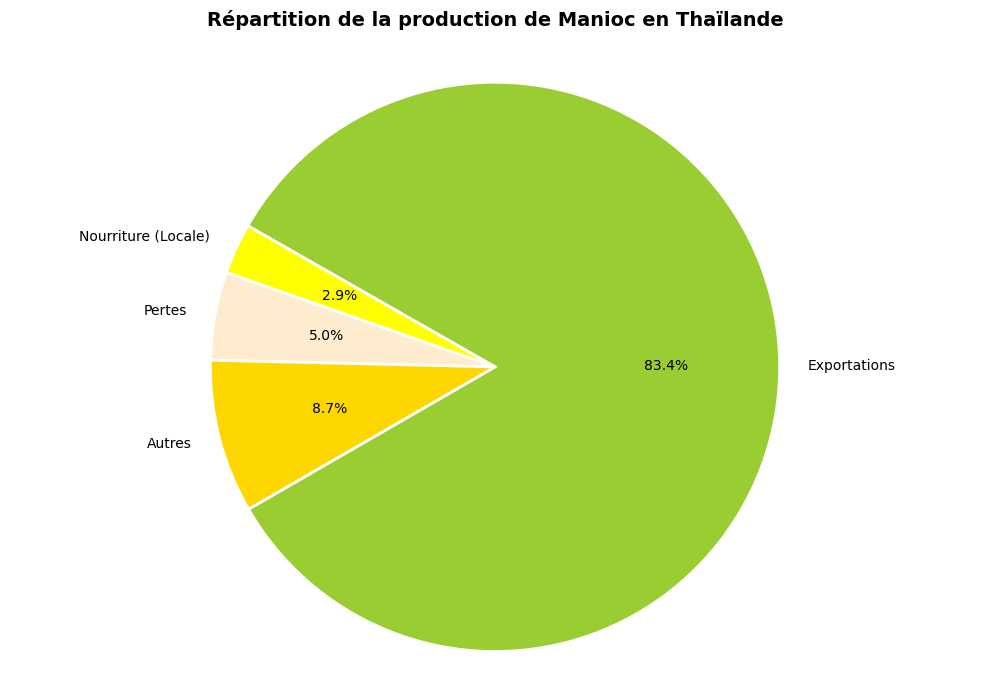

In [89]:
import matplotlib.pyplot as plt

# 1. Préparation des données
df_thai = dispo_alimentaire[(dispo_alimentaire["Zone"] == "Thaïlande") & (dispo_alimentaire["Produit"] == "Manioc")]

labels_raw = ["Exportations", "Nourriture (Locale)", "Pertes", "Autres"]
export = df_thai["Exportations - Quantité"].values[0]
nourriture = df_thai["Nourriture"].values[0]
pertes = df_thai["Pertes"].values[0]
# Calcul du reste
autres = df_thai["Production"].values[0] - (export + nourriture + pertes)

volumes = [export, nourriture, pertes, autres]

# 2. Création du graphique
plt.figure(figsize=(10, 7))

# Palette de couleurs
colors = ["yellowgreen", "yellow", "blanchedalmond", "gold"]

# On passe le startangle à 210 pour faire descendre "Exportations" 
# et pousser "Nourriture (Locale)" vers la droite
plt.pie(volumes, 
        labels=labels_raw, 
        autopct="%1.1f%%", 
        startangle=210,
        colors=colors, 
        wedgeprops={"edgecolor": "white", "linewidth": 2})

# 3. Titre et affichage
plt.title("Répartition de la production de Manioc en Thaïlande", 
          fontsize=14, fontweight="bold", pad=20)

plt.axis("equal") 
plt.tight_layout()
plt.show()

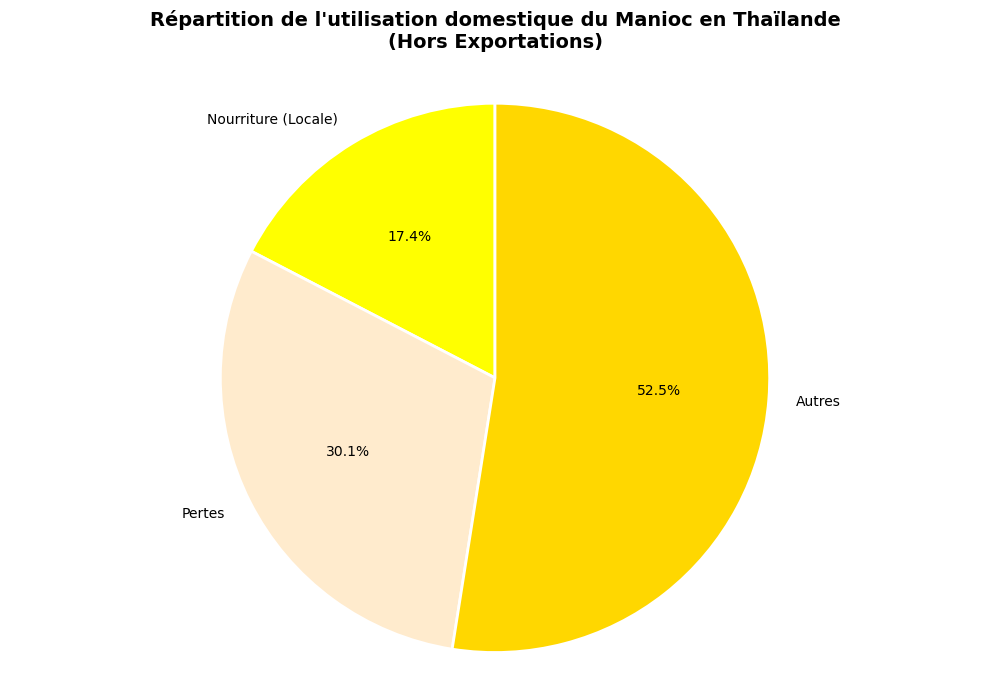

In [90]:
import matplotlib.pyplot as plt

# 1. Préparation des données
df_thai = dispo_alimentaire[(dispo_alimentaire["Zone"] == "Thaïlande") & (dispo_alimentaire["Produit"] == "Manioc")]

# On exclut l"exportation des labels et des calculs de volumes
labels_raw = ["Nourriture (Locale)", "Pertes", "Autres"]

nourriture = df_thai["Nourriture"].values[0]
pertes = df_thai["Pertes"].values[0]
export = df_thai["Exportations - Quantité"].values[0]
# Le reste (Autres) est calculé par rapport à la production totale moins l"export et le reste
autres = df_thai["Production"].values[0] - (export + nourriture + pertes)

# On ne garde que ces trois catégories
volumes = [nourriture, pertes, autres]

# 2. Création du graphique
plt.figure(figsize=(10, 7))

# On ajuste la palette pour les 3 segments restants
colors = ["yellow", "blanchedalmond", "gold"]

# On peut remettre un startangle plus standard ou l"ajuster selon ta préférence
plt.pie(volumes, 
        labels=labels_raw, 
        autopct="%1.1f%%", 
        startangle=90, 
        colors=colors, 
        wedgeprops={"edgecolor": "white", "linewidth": 2})

# 3. Titre adapté
plt.title("Répartition de l'utilisation domestique du Manioc en Thaïlande\n(Hors Exportations)", 
          fontsize=14, fontweight="bold", pad=20)

plt.axis("equal") 
plt.tight_layout()
plt.show()

In [91]:
##Calcul de la population en sous-nutrition en Thaïlande (moyenne 2016-2018)
thailande_sn = sous_nutrition[(sous_nutrition['Zone'] == 'Thaïlande') & 
                                 (sous_nutrition['Année'] == '2016-2018')].copy()
thailande_sn['nb_sous_nutrition'] = pd.to_numeric(thailande_sn['sous_nutrition'], errors='coerce')
nb_sn_thai = thailande_sn['nb_sous_nutrition'].values[0]

##Calcul du potentiel calorique du manioc produit -> On récupère les kcal/personne/jour et la nourriture (en milliers de tonnes)
manioc_thai = dispo_alimentaire[(dispo_alimentaire['Zone'] == 'Thaïlande') & 
                                   (dispo_alimentaire['Produit'] == 'Manioc')]

##Calcul de l'énergie totale disponible dans le manioc produit (Production) -> On utilise la dispo alimentaire pour estimer le ratio kcal/kg
dispo_kcal_p_j = manioc_thai['Disponibilité alimentaire (Kcal/personne/jour)'].values[0]
dispo_kg_p_an = manioc_thai['Disponibilité alimentaire en quantité (kg/personne/an)'].values[0]

ratio_kcal_kg = (dispo_kcal_p_j * 365) / dispo_kg_p_an

prod_manioc_kg = manioc_thai['Production'].values[0]

##Nombre de personnes que l'on pourrait nourrir (sur la base de 2500 kcal/jour)
potentiel_nourri = (prod_manioc_kg * ratio_kcal_kg) / (2500 * 365)

print(f"La Thaïlande compte {nb_sn_thai:,.0f} personnes en sous-nutrition.")
print(f"Sa production de manioc pourrait théoriquement nourrir {potentiel_nourri:,.0f} personnes.")

La Thaïlande compte 6,200,000 personnes en sous-nutrition.
Sa production de manioc pourrait théoriquement nourrir 37,203,692 personnes.


In [92]:
##Extraction des données de sous-nutrition pour la Thaïlande en 2017
sn_thailande = df_snut_2017.loc[df_snut_2017['Zone'] == 'Thaïlande']

print(f"Proportion de la population en sous-nutrition en Thaïlande : {sn_thailande['Proportion_pays'].values[0]}%")
print(f"Proportion de Manioc exportée : {proportion_exportee_manioc}%")

Proportion de la population en sous-nutrition en Thaïlande : 8.96%
Proportion de Manioc exportée : 13809    83.41273
dtype: float64%


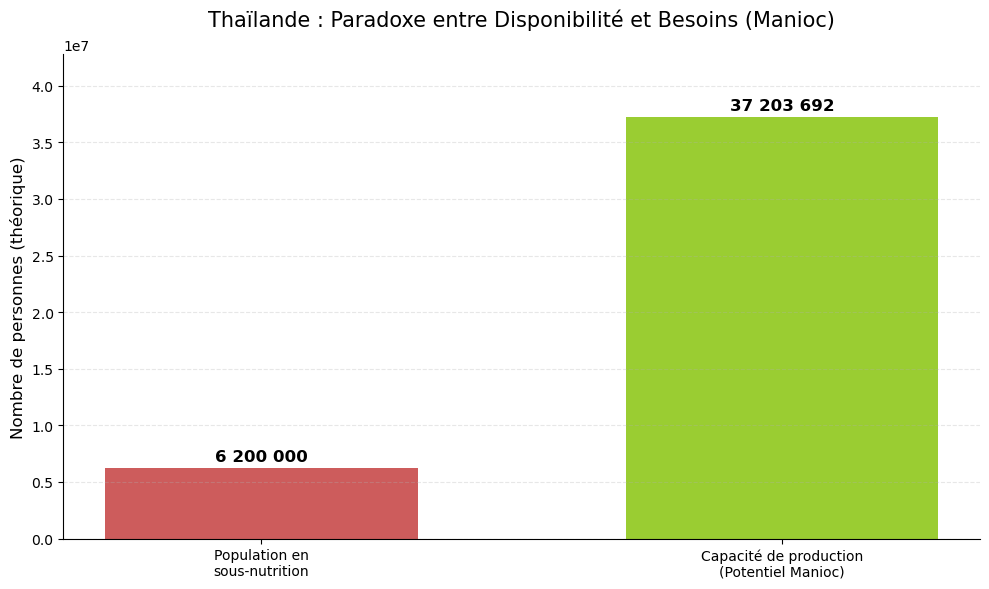

In [93]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Population en\nsous-nutrition', 'Capacité de production\n(Potentiel Manioc)']
valeurs = [nb_sn_thai, potentiel_nourri]

plt.figure(figsize=(10, 6))
colors = ["indianred", "yellowgreen"] # Rouge corail pour le besoin, Vert eau pour le potentiel

bars = plt.bar(categories, valeurs, color=colors, width=0.6)

# Ajout des étiquettes de données (formatées avec séparateur de milliers)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(valeurs) * 0.01), 
             f'{yval:,.0f}'.replace(',', ' '), 
             va='bottom', ha='center', fontweight='bold', fontsize=12)

plt.title('Thaïlande : Paradoxe entre Disponibilité et Besoins (Manioc)', fontsize=15, pad=20)
plt.ylabel('Nombre de personnes (théorique)', fontsize=12)
plt.ylim(0, max(valeurs) * 1.15) # Laisse de l'espace pour les étiquettes
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Suppression des bordures en haut et à droite
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()